In [2]:
import os
import shutil
import random
from pathlib import Path
from sklearn.model_selection import train_test_split
from google.colab import drive

# ==========================================
# 1. MOUNT DRIVE AND COPY DATA LOCALLY
# ==========================================
drive.mount('/content/drive')

# Copy data locally to avoid Google Drive I/O bottlenecks during training
!cp -r "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/multiclass_classification" "/content/dataset_original_local"

Mounted at /content/drive


In [4]:
import os
import shutil
import random
from pathlib import Path
from sklearn.model_selection import train_test_split

def get_patient_id(filename):
    """Extracts a unique patient ID from the filename."""
    parts = filename.split('-')
    if len(parts) >= 3:
        return f"{parts[1]}-{parts[2]}"
    return filename

def process_dataset_patient_split_3way(origin_path, final_path='/content/data_split_8classes', seed=42):
    random.seed(seed)
    origin = Path(origin_path)
    final_p = Path(final_path)

    if final_p.exists():
        print(f"Erasing old directory '{final_p}'...")
        shutil.rmtree(final_p)

    zooms = [f.name for f in origin.iterdir() if f.is_dir()]
    print(f"Detected zooms: {zooms}\n")

    extensions = ('*.png', '*.jpg', '*.jpeg', '*.tiff', '*.bmp')
    total_train, total_val, total_test = 0, 0, 0

    for amp in zooms:
        classes = [d.name for d in (origin / amp).iterdir() if d.is_dir()]
        patients_dict = {c: {} for c in classes}

        # Group images by patient ID for each class
        for c in classes:
            for ext in extensions:
                for img in (origin / amp / c).glob(ext):
                    p_id = get_patient_id(img.name)
                    if p_id not in patients_dict[c]:
                        patients_dict[c][p_id] = []
                    patients_dict[c][p_id].append(img)

        amp_train, amp_val, amp_test = 0, 0, 0

        for c in classes:
            all_patients = list(patients_dict[c].keys())

            # Split logic: 15% Test, 10% Val, 75% Train
            if len(all_patients) > 2:
                # First split: 15% for Test, 85% for Train+Val
                train_val_p, test_p = train_test_split(all_patients, test_size=0.15, random_state=seed)
                # Second split: ~11.76% of the 85% equals 10% of the total
                train_p, val_p = train_test_split(train_val_p, test_size=0.1176, random_state=seed)
            else:
                # Fallback for extremely small classes
                train_p, val_p, test_p = all_patients, [], []

            # Create hermetic destination folders
            for split_name in ['train', 'val', 'test']:
                (final_p / split_name / c).mkdir(parents=True, exist_ok=True)

            # Copy files adding zoom prefix
            for split_patients, split_name in zip([train_p, val_p, test_p], ['train', 'val', 'test']):
                for p_id in split_patients:
                    for img in patients_dict[c][p_id]:
                        shutil.copy(img, final_p / split_name / c / f"{amp}_{img.name}")

                        if split_name == 'train': amp_train += 1
                        elif split_name == 'val': amp_val += 1
                        elif split_name == 'test': amp_test += 1

        print(f" Zoom {amp} processed:")
        print(f"   - TRAIN: {amp_train} | VAL: {amp_val} | TEST: {amp_test}")

        total_train += amp_train
        total_val += amp_val
        total_test += amp_test

    print("-" * 50)
    print("The 75/10/15 patient-level split has finished successfully.")
    print(f"New clean data stored in: '{final_path}/'")
    print(f"Total TRAIN: {total_train} | Total VAL: {total_val} | Total TEST: {total_test}")

# =====================================================================
# EXECUTION
# =====================================================================
source_path = '/content/dataset_original_local'
local_dest_path = '/content/data_split_8classes'

process_dataset_patient_split_3way(origin_path=source_path, final_path=local_dest_path)

Detected zooms: ['100X', '200X', '400X', '40X']

 Zoom 100X processed:
   - TRAIN: 1366 | VAL: 283 | TEST: 432
 Zoom 200X processed:
   - TRAIN: 1341 | VAL: 286 | TEST: 386
 Zoom 400X processed:
   - TRAIN: 1154 | VAL: 325 | TEST: 341
 Zoom 40X processed:
   - TRAIN: 1223 | VAL: 298 | TEST: 474
--------------------------------------------------
The 75/10/15 patient-level split has finished successfully.
New clean data stored in: '/content/data_split_8classes/'
Total TRAIN: 5084 | Total VAL: 1192 | Total TEST: 1633


In [5]:
import torch
import numpy as np
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, WeightedRandomSampler

# ==========================================
# 1. DATA AUGMENTATION & TRANSFORMS
# ==========================================
# Data Augmentation applied ONLY to the training set
transform_train_da = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation and Test sets must NOT be augmented
transform_val_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ==========================================
# 2. DATASETS DEFINITION (8 CLASSES)
# ==========================================
# Pointing to the new strictly isolated split folders
train_dir = '/content/data_split_8classes/train'
val_dir = '/content/data_split_8classes/val'
test_dir = '/content/data_split_8classes/test'

train_dataset = datasets.ImageFolder(root=train_dir, transform=transform_train_da)
val_dataset = datasets.ImageFolder(root=val_dir, transform=transform_val_test)
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform_val_test)

# ==========================================
# 3. CLASS BALANCING TO MAJORITY CLASS
# ==========================================
# Count the number of images per class in the training set
class_counts = np.bincount(train_dataset.targets)
max_class_count = max(class_counts)

# Calculate weights inversely proportional to class frequencies
class_weights = 1.0 / class_counts
sample_weights = np.array([class_weights[t] for t in train_dataset.targets])
sample_weights = torch.from_numpy(sample_weights).double()

# Force the epoch to have balanced classes up to the majority class limit
num_classes = len(train_dataset.classes)
balanced_num_samples = int(max_class_count * num_classes)

# Create the sampler (replacement=True allows reusing minority class images)
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=balanced_num_samples, replacement=True)

# ==========================================
# 4. DATALOADERS
# ==========================================
# IMPORTANT: shuffle MUST be False when using a sampler
train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"Original Train images: {len(train_dataset)}")
print(f"Effective Train images per epoch (after DA balancing): {balanced_num_samples}")
print(f"Validation images: {len(val_dataset)}")
print(f"Test images: {len(test_dataset)}")
print(f"Detected Classes: {train_dataset.class_to_idx}")

Original Train images: 5084
Effective Train images per epoch (after DA balancing): 20232
Validation images: 1192
Test images: 1633
Detected Classes: {'adenosis': 0, 'ductal_carcinoma': 1, 'fibroadenoma': 2, 'lobular_carcinoma': 3, 'mucinous_carcinoma': 4, 'papillary_carcinoma': 5, 'phyllodes_tumor': 6, 'tubular_adenoma': 7}


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import models

# ==========================================
# 5. FOCAL LOSS DEFINITION
# ==========================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        """
        Focal Loss for multi-class classification.
        Penalizes confident predictions to focus on hard, misclassified examples.
        """
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.reduction = reduction
        self.alpha = alpha

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

# ==========================================
# 6. EARLY STOPPING CLASS
# ==========================================
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0):
        """
        Stops training when validation loss stops improving.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

# ==========================================
# 7. CNN MODEL INITIALIZATION (ResNet18)
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

# Load pre-trained ResNet18 as in the original code
weights = models.ResNet18_Weights.IMAGENET1K_V1
model_cnn = models.resnet18(weights=weights)

# Keep all layers unfrozen for full fine-tuning (Purist approach)
for param in model_cnn.parameters():
    param.requires_grad = True

# Modify the final layer for the detected number of classes (8)
num_ftrs = model_cnn.fc.in_features
model_cnn.fc = nn.Linear(num_ftrs, num_classes)
model_cnn = model_cnn.to(device)

# Replace CrossEntropyLoss with the requested FocalLoss
criterion = FocalLoss(gamma=2.0)

# Keep the original optimizer configuration
optimizer_cnn = optim.Adam(model_cnn.parameters(), lr=0.0001)

print(f"ResNet18 architecture ready for {num_classes}-class classification with Focal Loss.")

Training on device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 200MB/s]


ResNet18 architecture ready for 8-class classification with Focal Loss.


In [7]:
import time
import copy
import torch
from sklearn.metrics import classification_report

# ==========================================
# 8. TRAINING PHASE WITH EARLY STOPPING
# ==========================================
MAX_EPOCHS = 100
early_stopping = EarlyStopping(patience=10)

print("Starting training for the Data Augmentation experiment with 8 classes...\n")

# Variables to keep track of the best model
best_model_wts = copy.deepcopy(model_cnn.state_dict())
best_acc = 0.0

for epoch in range(MAX_EPOCHS):
    start_time = time.time()

    # ==========================================
    # TRAINING PHASE
    # ==========================================
    model_cnn.train()
    running_loss = 0.0
    running_corrects = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer_cnn.zero_grad()

        outputs = model_cnn(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer_cnn.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total_train += inputs.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = running_corrects.float() / total_train

    # ==========================================
    # VALIDATION PHASE
    # ==========================================
    model_cnn.eval()
    running_val_loss = 0.0
    running_val_corrects = 0
    total_val = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model_cnn(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            running_val_loss += loss.item() * inputs.size(0)
            running_val_corrects += torch.sum(preds == labels.data)
            total_val += inputs.size(0)

    epoch_val_loss = running_val_loss / total_val
    epoch_val_acc = running_val_corrects.float() / total_val

    epoch_time = time.time() - start_time

    print(f"Epoch {epoch+1}/{MAX_EPOCHS} ({epoch_time:.1f}s) -> "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} || "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

    # Deep copy the model if it has the best validation accuracy
    if epoch_val_acc > best_acc:
        best_acc = epoch_val_acc
        best_model_wts = copy.deepcopy(model_cnn.state_dict())

    # Check Early Stopping based on validation loss
    early_stopping(epoch_val_loss)
    if early_stopping.early_stop:
        print(f"\nEarly stopping triggered at epoch {epoch+1}!")
        break

print(f"\nTraining finished successfully. Best Validation Accuracy: {best_acc:.4f}")

# ==========================================
# 9. LOAD BEST MODEL & SAVE
# ==========================================
# Load the best weights into the model
model_cnn.load_state_dict(best_model_wts)

# Save the best model to Google Drive
save_path = "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/multiclass_classification/cnn_ResNet18_DA_8classes.pth"
torch.save(model_cnn.state_dict(), save_path)
print(f"Model saved as 'cnn_ResNet18_DA_8classes.pth'")

Starting training for the Data Augmentation experiment with 8 classes...

Epoch 1/100 (105.6s) -> Train Loss: 0.2144 | Train Acc: 0.8508 || Val Loss: 2.3752 | Val Acc: 0.4765
Epoch 2/100 (105.3s) -> Train Loss: 0.0621 | Train Acc: 0.9405 || Val Loss: 2.3787 | Val Acc: 0.5134
Epoch 3/100 (107.5s) -> Train Loss: 0.0500 | Train Acc: 0.9538 || Val Loss: 2.5919 | Val Acc: 0.5185
Epoch 4/100 (105.1s) -> Train Loss: 0.0355 | Train Acc: 0.9657 || Val Loss: 2.7320 | Val Acc: 0.5378
Epoch 5/100 (104.8s) -> Train Loss: 0.0330 | Train Acc: 0.9669 || Val Loss: 3.0284 | Val Acc: 0.5034
Epoch 6/100 (108.0s) -> Train Loss: 0.0316 | Train Acc: 0.9709 || Val Loss: 2.6078 | Val Acc: 0.5252
Epoch 7/100 (105.1s) -> Train Loss: 0.0310 | Train Acc: 0.9710 || Val Loss: 3.0307 | Val Acc: 0.5428
Epoch 8/100 (104.9s) -> Train Loss: 0.0194 | Train Acc: 0.9800 || Val Loss: 3.1703 | Val Acc: 0.5319
Epoch 9/100 (104.4s) -> Train Loss: 0.0249 | Train Acc: 0.9748 || Val Loss: 2.9566 | Val Acc: 0.5008
Epoch 10/100 (101

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import models

# ==========================================
# 5. FOCAL LOSS DEFINITION
# ==========================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.reduction = reduction
        self.alpha = alpha

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

# ==========================================
# 6. EARLY STOPPING CLASS
# ==========================================
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0


Training on device: cuda
ResNet18 architecture ready for 8-class classification with Regularization.


In [10]:
# ==========================================
# 7. CNN MODEL INITIALIZATION (ResNet18) - FULL FINE-TUNING REGULARIZED
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

weights = models.ResNet18_Weights.IMAGENET1K_V1
model_cnn = models.resnet18(weights=weights)

# 1. FULL FINE-TUNING: Unfreeze all layers so they can learn medical features
for param in model_cnn.parameters():
    param.requires_grad = True

# 2. DROPOUT: Add a regularization layer before the final classification
num_ftrs = model_cnn.fc.in_features
model_cnn.fc = nn.Sequential(
    nn.Dropout(p=0.5), # Randomly zeroes 50% of elements to prevent co-adaptation
    nn.Linear(num_ftrs, num_classes)
)
model_cnn = model_cnn.to(device)

criterion = FocalLoss(gamma=2.0)

# 3. WEIGHT DECAY: Apply L2 penalty to ALL parameters now that they are unfrozen
# We use a slightly smaller weight decay (1e-4) to allow the network to learn while still penalizing large weights
optimizer_cnn = optim.Adam(model_cnn.parameters(), lr=0.0001, weight_decay=1e-4)

print(f"ResNet18 architecture ready for {num_classes}-class classification with Full Fine-Tuning and Regularization.")

Training on device: cuda
ResNet18 architecture ready for 8-class classification with Full Fine-Tuning and Regularization.


In [12]:
import time
import copy
import torch
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support

# ==========================================
# 8. TRAINING PHASE WITH EARLY STOPPING
# ==========================================
MAX_EPOCHS = 100
early_stopping = EarlyStopping(patience=10)

print("Starting training for the Full Fine-Tuning Regularized 8-Class Experiment...\n")

# Variables to keep track of the best model
best_model_wts = copy.deepcopy(model_cnn.state_dict())
best_acc = 0.0

for epoch in range(MAX_EPOCHS):
    start_time = time.time()

    # ==========================================
    # TRAINING PHASE
    # ==========================================
    model_cnn.train()  # Set model to training mode (enables Dropout)
    running_loss = 0.0
    running_corrects = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer_cnn.zero_grad()

        outputs = model_cnn(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer_cnn.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total_train += inputs.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = running_corrects.float() / total_train

    # ==========================================
    # VALIDATION PHASE
    # ==========================================
    model_cnn.eval()  # Set model to evaluate mode (disables Dropout)
    running_val_loss = 0.0
    running_val_corrects = 0
    total_val = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model_cnn(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            running_val_loss += loss.item() * inputs.size(0)
            running_val_corrects += torch.sum(preds == labels.data)
            total_val += inputs.size(0)

    epoch_val_loss = running_val_loss / total_val
    epoch_val_acc = running_val_corrects.float() / total_val

    epoch_time = time.time() - start_time

    print(f"Epoch {epoch+1}/{MAX_EPOCHS} ({epoch_time:.1f}s) -> "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} || "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

    # Deep copy the model if it has the best validation accuracy
    if epoch_val_acc > best_acc:
        best_acc = epoch_val_acc
        best_model_wts = copy.deepcopy(model_cnn.state_dict())

    # Check Early Stopping based on validation loss
    early_stopping(epoch_val_loss)
    if early_stopping.early_stop:
        print(f"\nEarly stopping triggered at epoch {epoch+1}!")
        break

print(f"\nTraining finished successfully. Best Validation Accuracy: {best_acc:.4f}")

# ==========================================
# 9. LOAD BEST MODEL & SAVE
# ==========================================
# Load the best weights into the model
model_cnn.load_state_dict(best_model_wts)

# Save the best model to Google Drive
save_path = "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/multiclass_classification/cnn_ResNet18_FullFineTuned_8classes.pth"
torch.save(model_cnn.state_dict(), save_path)
print(f"Model saved as 'cnn_ResNet18_FullFineTuned_8classes.pth'")

# ==========================================
# 10. EVALUATION ON TEST SET (15%)
# ==========================================
print("\nEvaluating best full fine-tuned CNN model on the Test Set...")
model_cnn.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model_cnn(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Extract class names to map the results correctly
class_names = train_dataset.classes

# Calculate specific metrics to ensure all 4 requested metrics are presented
accuracy = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted', zero_division=0)

print("\n" + "="*60)
print(f"OVERALL TEST PERFORMANCE METRICS:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f} (Weighted)")
print(f"Recall:    {recall:.4f} (Weighted)")
print(f"F1-Score:  {f1:.4f} (Weighted)")
print("="*60 + "\n")

print("Detailed Classification Report per Class:")
print("-" * 60)
print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))
print("-" * 60)

Starting training for the Full Fine-Tuning Regularized 8-Class Experiment...

Epoch 1/100 (101.6s) -> Train Loss: 0.0258 | Train Acc: 0.9748 || Val Loss: 3.0248 | Val Acc: 0.5495
Epoch 2/100 (101.9s) -> Train Loss: 0.0275 | Train Acc: 0.9738 || Val Loss: 3.1875 | Val Acc: 0.5386
Epoch 3/100 (100.9s) -> Train Loss: 0.0216 | Train Acc: 0.9787 || Val Loss: 2.8274 | Val Acc: 0.5327
Epoch 4/100 (99.9s) -> Train Loss: 0.0248 | Train Acc: 0.9766 || Val Loss: 3.1904 | Val Acc: 0.5151
Epoch 5/100 (100.8s) -> Train Loss: 0.0279 | Train Acc: 0.9747 || Val Loss: 3.4746 | Val Acc: 0.5503
Epoch 6/100 (100.2s) -> Train Loss: 0.0192 | Train Acc: 0.9812 || Val Loss: 3.5028 | Val Acc: 0.5327
Epoch 7/100 (100.8s) -> Train Loss: 0.0189 | Train Acc: 0.9825 || Val Loss: 2.8740 | Val Acc: 0.5403
Epoch 8/100 (101.5s) -> Train Loss: 0.0248 | Train Acc: 0.9772 || Val Loss: 3.0082 | Val Acc: 0.5453
Epoch 9/100 (102.8s) -> Train Loss: 0.0220 | Train Acc: 0.9799 || Val Loss: 3.2173 | Val Acc: 0.5210
Epoch 10/100 (

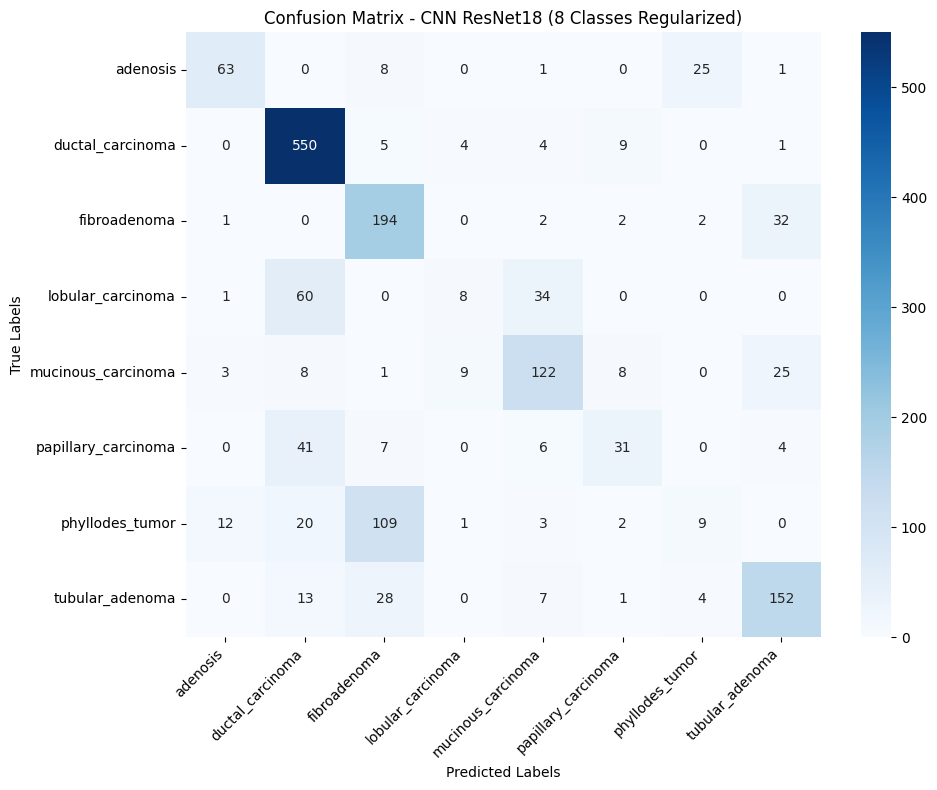

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ==========================================
# 11. CONFUSION MATRIX (CNN - 8 CLASSES)
# ==========================================

# Generate the confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot the confusion matrix using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - CNN ResNet18 (8 Classes Regularized)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# plt.savefig('cnn_8classes_regularized_cm.png', dpi=300) # Uncomment to save the image
plt.show()

Training on device: cuda
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 129MB/s]


ViT architecture ready for 8-class classification.

Starting training for the ViT 8-Class Experiment...

Epoch 1/100 (760.5s) -> Train Loss: 0.2262 | Train Acc: 0.8426 || Val Loss: 2.2291 | Val Acc: 0.5352
Epoch 2/100 (759.3s) -> Train Loss: 0.0525 | Train Acc: 0.9488 || Val Loss: 1.8452 | Val Acc: 0.5612
Epoch 3/100 (757.5s) -> Train Loss: 0.0424 | Train Acc: 0.9604 || Val Loss: 1.9623 | Val Acc: 0.5185
Epoch 4/100 (759.9s) -> Train Loss: 0.0387 | Train Acc: 0.9634 || Val Loss: 2.2496 | Val Acc: 0.5319
Epoch 5/100 (756.8s) -> Train Loss: 0.0394 | Train Acc: 0.9629 || Val Loss: 2.1498 | Val Acc: 0.5403
Epoch 6/100 (758.8s) -> Train Loss: 0.0355 | Train Acc: 0.9646 || Val Loss: 2.2780 | Val Acc: 0.5050
Epoch 7/100 (760.1s) -> Train Loss: 0.0322 | Train Acc: 0.9665 || Val Loss: 1.8752 | Val Acc: 0.5495
Epoch 8/100 (758.0s) -> Train Loss: 0.0346 | Train Acc: 0.9673 || Val Loss: 2.0650 | Val Acc: 0.5143
Epoch 9/100 (759.3s) -> Train Loss: 0.0375 | Train Acc: 0.9634 || Val Loss: 2.2442 | Va

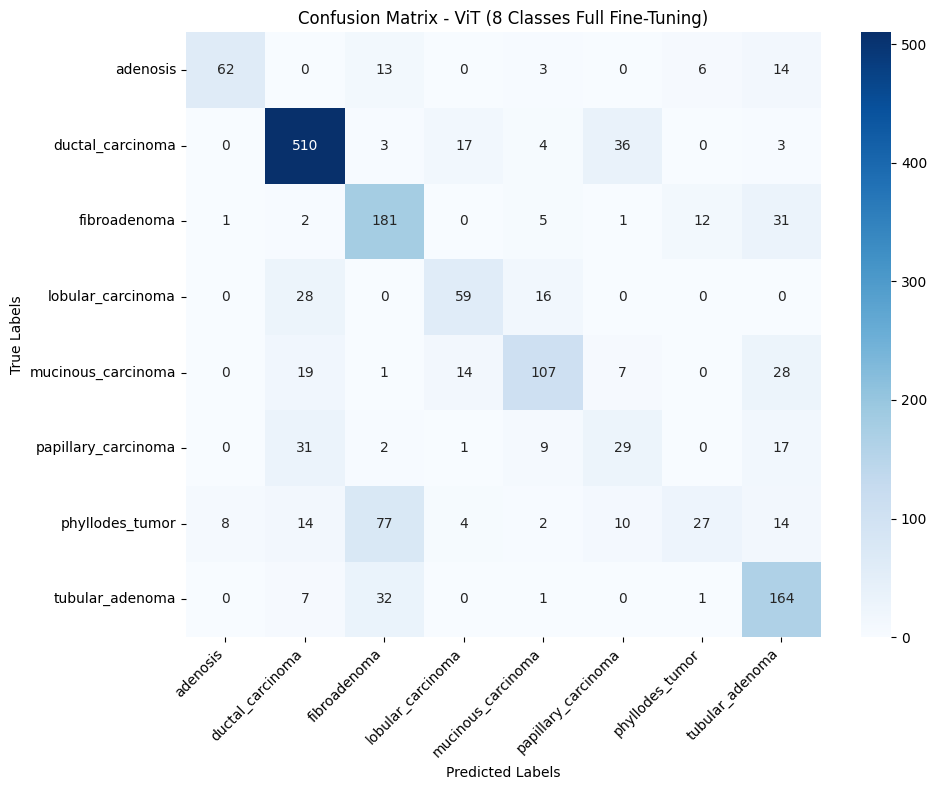

In [14]:
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. ViT MODEL INITIALIZATION (8 CLASSES)
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

# Load pre-trained Vision Transformer (ViT Base 16)
model_vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

# Unfreeze all layers for full fine-tuning
for param in model_vit.parameters():
    param.requires_grad = True

# Modify the classification head for the 8 classes
num_ftrs = model_vit.heads.head.in_features
num_classes = len(train_dataset.classes)
model_vit.heads.head = nn.Linear(num_ftrs, num_classes)
model_vit = model_vit.to(device)

# Focal Loss and Optimizer (using weight decay for regularization)
criterion_vit = FocalLoss(gamma=2.0)
optimizer_vit = optim.Adam(model_vit.parameters(), lr=0.0001, weight_decay=1e-4)

print(f"ViT architecture ready for {num_classes}-class classification.")

# ==========================================
# 2. TRAINING PHASE WITH EARLY STOPPING
# ==========================================
MAX_EPOCHS = 100
early_stopping_vit = EarlyStopping(patience=10)

print("\nStarting training for the ViT 8-Class Experiment...\n")

best_model_wts_vit = copy.deepcopy(model_vit.state_dict())
best_acc_vit = 0.0

for epoch in range(MAX_EPOCHS):
    start_time = time.time()

    # --- TRAINING PHASE ---
    model_vit.train()
    running_loss = 0.0
    running_corrects = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer_vit.zero_grad()

        outputs = model_vit(inputs)
        loss = criterion_vit(outputs, labels)

        loss.backward()
        optimizer_vit.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total_train += inputs.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = running_corrects.float() / total_train

    # --- VALIDATION PHASE ---
    model_vit.eval()
    running_val_loss = 0.0
    running_val_corrects = 0
    total_val = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model_vit(inputs)
            loss = criterion_vit(outputs, labels)

            _, preds = torch.max(outputs, 1)
            running_val_loss += loss.item() * inputs.size(0)
            running_val_corrects += torch.sum(preds == labels.data)
            total_val += inputs.size(0)

    epoch_val_loss = running_val_loss / total_val
    epoch_val_acc = running_val_corrects.float() / total_val
    epoch_time = time.time() - start_time

    print(f"Epoch {epoch+1}/{MAX_EPOCHS} ({epoch_time:.1f}s) -> "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} || "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

    if epoch_val_acc > best_acc_vit:
        best_acc_vit = epoch_val_acc
        best_model_wts_vit = copy.deepcopy(model_vit.state_dict())

    early_stopping_vit(epoch_val_loss)
    if early_stopping_vit.early_stop:
        print(f"\nEarly stopping triggered at epoch {epoch+1}!")
        break

print(f"\nTraining finished successfully. Best Validation Accuracy: {best_acc_vit:.4f}")

# ==========================================
# 3. LOAD BEST MODEL & SAVE
# ==========================================
model_vit.load_state_dict(best_model_wts_vit)
save_path_vit = "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/multiclass_classification/vit_FullFineTuned_8classes.pth"
torch.save(model_vit.state_dict(), save_path_vit)
print(f"Model saved as 'vit_FullFineTuned_8classes.pth'")

# ==========================================
# 4. EVALUATION ON TEST SET (15%) & METRICS
# ==========================================
print("\nEvaluating best ViT model on the Test Set...")
model_vit.eval()
all_preds_vit = []
all_labels_vit = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model_vit(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds_vit.extend(preds.cpu().numpy())
        all_labels_vit.extend(labels.cpu().numpy())

class_names = train_dataset.classes

accuracy = accuracy_score(all_labels_vit, all_preds_vit)
precision, recall, f1, _ = precision_recall_fscore_support(all_labels_vit, all_preds_vit, average='weighted', zero_division=0)

print("\n" + "="*60)
print(f"OVERALL TEST PERFORMANCE METRICS (ViT):")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f} (Weighted)")
print(f"Recall:    {recall:.4f} (Weighted)")
print(f"F1-Score:  {f1:.4f} (Weighted)")
print("="*60 + "\n")

print("Detailed Classification Report per Class:")
print("-" * 60)
print(classification_report(all_labels_vit, all_preds_vit, target_names=class_names, zero_division=0))
print("-" * 60)

# ==========================================
# 5. CONFUSION MATRIX (ViT - 8 CLASSES)
# ==========================================
cm_vit = confusion_matrix(all_labels_vit, all_preds_vit)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_vit, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - ViT (8 Classes Full Fine-Tuning)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# plt.savefig('vit_8classes_confusion_matrix.png', dpi=300)
plt.show()